## Data Sampling

Training of LLMs is done in an autoregressive way meaning that the model takes a set of words or tokens as input and outputs the estimated next word.

This process is called self-supervised learning because of its natural implementation way. We don't have to label the outputs manually. It will be automatically done and used in training process.

Here, there is an important parameter called `context_length` or `context_size` which defines the length of the set of input tokens to be used for the next word prediction at the same time. For example, if the `context_size` is selected as 4, then the model will predict the 5th token by using preceding 4 tokens. Then, it will slide by the `window_size` and continue for the next token predictions. 

In order to create the training data using the token, we need to go through the following steps:
1. Import the raw text data and tokenize the words or sub-words
2. Create a tokenizer (we can use BPE tokenizer from tiktoken)
3. Use a for loop to select `n-1` tokens as the training input and `n`th element as training output
    * In this step we need to define two parameters: `context_size` and `window_size`
4. Check the implementation using a test-case.

### Step 1: Import the text to be used for the generation of training data

In [1]:
from pathlib import Path


f_path = Path("../data/the-verdict.txt")
with open(f_path, 'r', encoding="utf-8") as f:
    raw_text = f.read()

print(len(raw_text))
print(raw_text[:50])

20479
I HAD always thought Jack Gisburn rather a cheap g


### Step 2: Create the tokenizer

In [2]:
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

sample_length = 29
enc_sample = enc_text[:sample_length]
print(enc_sample)

5145
[40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438, 568, 340, 373, 645, 1049, 5975, 284, 502, 284]


### Step 3: Implement Data Sampler

In [3]:
from typing import List


class DataSamplerV1:

    def __init__(self, token_list: List[int], context_size: int, window_size: int):
        self.token_list = token_list
        self.context_size = context_size
        self.window_size = window_size

        self.features = []
        self.labels = []

    def create_dataset(self):
        for idx in range(0, len(self.token_list) - self.context_size, self.window_size):
            self.features.append(self.token_list[idx : idx + self.context_size])
            self.labels.append(self.token_list[idx + 1 : idx + self.context_size + 1])

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

sampler = DataSamplerV1(enc_sample, context_size=4, window_size=4)
sampler.create_dataset()
X, y = sampler[-2:]
for k, v in zip(X, y):
    print(f"Token: {k} -> {v}")
    print(f"Text: {tokenizer.decode(k)} -> {tokenizer.decode(v)}")
    print("")

print("Total length of dataset: ", len(sampler))

Token: [568, 340, 373, 645] -> [340, 373, 645, 1049]
Text: so it was no ->  it was no great

Token: [1049, 5975, 284, 502] -> [5975, 284, 502, 284]
Text:  great surprise to me ->  surprise to me to

Total length of dataset:  7


So far, we have implemented a basic data sampler class, `DataSamplerV1`. Now, we can turn the sampler class a torch dataset and implement a dataloader to use the dataset.

Hence, it will support torch tensors and be ready for the training.

### Improve the sampler to a dataset and dataloader

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):

    def __init__(self, text: str, tokenizer: tiktoken.Encoding, context_size: int, window_size: int):
        self.context_size = context_size
        self.window_size = window_size
        self.token_ids = tokenizer.encode(text)
        self.inputs = []
        self.targets = []
        self.create_dataset()

    def create_dataset(self):
        for idx in range(0, len(self.token_ids) - self.context_size, self.window_size):
            input_chunk = self.token_ids[idx : idx + self.context_size]
            target_chunk = self.token_ids[idx + 1 : idx + self.context_size + 1]
            self.inputs.append(torch.tensor(input_chunk))
            self.targets.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]
    

def gpt_loader_v1(text: str, batch_size: int, context_size=256, window_size=128, shuffle=True, num_workers=0, drop_last=True):
    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDatasetV1(
        text=text,
        tokenizer=tokenizer,
        context_size=context_size,
        window_size=window_size
    )

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        drop_last=drop_last
    )

    return loader


f_path = Path("../data/the-verdict.txt")
with open(f_path, 'r', encoding="utf-8") as f:
    raw_text = f.read()

dataloader = gpt_loader_v1(raw_text, batch_size=1, context_size=4, window_size=1, shuffle=False)
data_iter = iter(dataloader)
print("First batch:")
print(next(data_iter))
print("")

dataloader = gpt_loader_v1(
    raw_text, batch_size=8, context_size=4, window_size=4, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

First batch:
[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


## Token Embedding

Up to now we have completed the generation of inputs and targets.

Now, we will continue with token embeddings. In other words, we will convert each token to embedding vectors which will provide us with the token sentiment relationship.

To that attempt, we need to define the size of the embedding vector and then initialize the embedding vectors with random values.

Let's create an embedding layer from inputs using `torch.nn.Embedding`.

In [5]:
context_size = inputs.shape[1]
embedding_size = 6  # selected arbitrarily

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(context_size, embedding_size)
print(embedding_layer.weight)
print("")

# print the 3rd index, input must be tensor not an integer
print(embedding_layer(torch.tensor(3)))

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.3035, -0.5880,  0.3486,  0.6603],
        [-0.2196, -0.3792, -0.1606, -0.4015,  0.6957, -1.8061],
        [ 1.8960, -0.1750,  1.3689, -1.6033, -0.7849, -1.4096],
        [-0.4076,  0.7953,  0.9985,  0.2212,  1.8319, -0.3378]],
       requires_grad=True)

tensor([-0.4076,  0.7953,  0.9985,  0.2212,  1.8319, -0.3378],
       grad_fn=<EmbeddingBackward0>)


Embedding layer performs a lookup operator.

![03_Token_embedding](../../images/03_Token_embedding.png)

## Positional Embedding

Since the embedding vector is just a look-up table, it does not represent the position of the token in the sentence. However, the word positions have critical impact for the LLM to understand the relationship between the words and the grammatical structure of the languages.

Therefore, in this section we will implement positional information to the embedding vector.

In the literature there are different types of positional embeddings like;
1. Absolute positional embeddings
    * Learned Positional Embeddings:
        * The model learns a position embedding matrix during training.
        * Each position has a trainable vector.
        * Pros: Can learn complex positional dependencies.
        * Cons: Limited to a fixed maximum sequence length.
    * Sinusoidal Positional Embeddings:
        * Uses sine and cosine functions of different frequencies.
        * 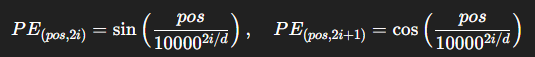
        * Used in the original Transformer paper
        * Pros: No training required, generalizes to longer sequences.
        * Cons: Less flexible than learned embeddings.
2. Relative positional embeddings:
    * These represent the distance between tokens, rather than their absolute position.
    * Allows the model to consider relative distances (e.g., how far one token is from another).
    * Pros: Handles variable-length sequences and longer contexts better.
    * Cons: More complex to implement.
3. Rotary positional embeddings
    * Encodes position by rotating token embeddings in a multi-dimensional space.
    * Pros: Efficient, extrapolates well, supports long context.
    * Cons: More mathematical complexity.

We will use the learned positional embedding with its absolute position.

In [ ]:
vocab_size = 50257  # number of unique BPE tokens in GPT-2's vocabulary
embedding_size = 256  # Original GPT2 embedding size

print("Inputs:")
print(inputs)
print("")

token_embedding_layer = torch.nn.Embedding(vocab_size, embedding_size)
print("Token Embedding Layer:")
print(token_embedding_layer)
print("")
print(token_embedding_layer.weight)
print("")

token_embeddings = token_embedding_layer(inputs)
print("Token Embeddings:")
print(token_embeddings.shape)
print("")

print(token_embeddings)

Inputs:
tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Token Embedding Layer:
Embedding(50257, 256)

Parameter containing:
tensor([[ 0.3369,  0.3555,  0.6646,  ..., -0.4975,  2.0092, -0.3129],
        [ 1.2774, -1.3890, -0.8947,  ...,  0.1083,  0.2163,  1.0807],
        [-0.7322, -0.5363,  1.0333,  ...,  0.8127,  0.2244,  0.2377],
        ...,
        [ 0.4057,  1.6600,  0.4663,  ..., -0.8235, -0.7763, -0.5501],
        [-0.4661, -0.6656, -1.1553,  ...,  0.1858,  0.1734, -0.1082],
        [ 0.7571,  1.4614, -0.0198,  ..., -1.0722, -0.9438,  1.3710]],
       requires_grad=True)

Token Embeddings:
torch.Size([8, 4, 256])

tensor([[[ 0.3817,  0.1213,  1.6726,  ...,  0.3078, -1.6167,  0.0247],
         [-0.1913,  0.3348,  1.0993,  ...,

In [62]:
print("Embedding vector corresponding to 40th token:")
print(token_embedding_layer.weight[40, :])
print("")

# the first row of the inputs is [   40,   367,  2885,  1464]
print("Embedding vector for the first row of inputs [   40,   367,  2885,  1464]: ")
print(token_embedding_layer(inputs[0, :]))
print("")
print("The first print is equal to the first embedding which is the embedding of 40.")

Embedding vector corresponding to 40th token:
tensor([ 0.3817,  0.1213,  1.6726, -1.7642,  0.5138, -0.0646,  1.1556,  0.4440,
        -0.6485,  1.4722,  1.2845,  1.4300,  0.7452, -0.3090, -0.2077,  0.1352,
        -0.2109,  0.1819, -0.1248, -0.3214,  1.3565,  2.1162, -0.7860,  1.2967,
         0.3458, -0.6409,  1.1678, -0.4298, -0.9671, -0.0745,  0.5032, -1.2655,
        -1.0746, -0.0972,  0.0514, -0.0978, -0.3125,  2.8414,  0.6064,  0.8411,
        -0.8856, -0.4936, -0.2615, -1.6275,  1.0051,  0.5152,  0.7078, -0.3969,
         1.6184,  1.0606, -1.4478, -1.0671,  0.3913, -1.4298,  0.1267,  0.7993,
        -0.0650, -0.3563,  1.2423,  0.0593,  0.1439,  0.2319,  1.0265,  0.2390,
        -1.4199,  0.6713, -0.9061,  0.2046,  0.0481,  1.5490, -0.4142,  2.1733,
         0.6476, -0.4638, -0.2178,  0.3910, -0.0655,  1.2723,  0.7066,  1.0029,
        -0.2329, -1.7288,  0.4779, -0.1889, -0.3785,  0.2456,  1.7814, -0.5348,
         0.4763,  1.5241,  2.0744,  0.0406,  0.1997,  1.3340, -2.0072, -0.

In [64]:
pos_embedding_layer = torch.nn.Embedding(context_size, embedding_size)
pos_embeddings = pos_embedding_layer(torch.arange(context_size))
print(pos_embeddings)
print("")
print(pos_embeddings.shape)

tensor([[ 1.0894, -1.6044,  1.5193,  ...,  0.1417, -0.3084,  0.4561],
        [-0.5057, -1.6266,  1.1765,  ..., -0.9749,  1.1575,  1.4884],
        [ 0.5564,  1.4918,  1.7501,  ..., -0.1929, -0.1846,  0.4458],
        [ 1.0114,  1.5001,  1.0280,  ..., -0.1831,  0.3932, -0.2444]],
       grad_fn=<EmbeddingBackward0>)

torch.Size([4, 256])


8 x 4 x 256 shaped token embedding matrix is automatically sumed by 4 x 256 shaped positional embedding matrix in PyTorch.

In [66]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)
print("")
print(input_embeddings)

torch.Size([8, 4, 256])

tensor([[[ 1.4711, -1.4831,  3.1919,  ...,  0.4496, -1.9251,  0.4808],
         [-0.6971, -1.2918,  2.2758,  ..., -2.2629,  1.1815,  0.5130],
         [-0.6263,  2.4296,  1.8318,  ...,  1.1039,  0.7458, -0.2516],
         [-1.0763,  0.4994,  2.2023,  ...,  1.1518,  1.1635, -0.1657]],

        [[-1.9080, -0.6277,  0.5928,  ..., -0.2751,  1.6076, -0.3992],
         [-0.1354, -2.7201,  3.0272,  ..., -1.6309,  0.5767, -0.1339],
         [ 1.2801,  1.2536,  1.0550,  ...,  0.9242, -1.7425, -0.5172],
         [ 0.1145,  0.5112,  2.0318,  ..., -1.2964, -0.1567,  1.7038]],

        [[ 2.3150, -0.8566,  1.9262,  ..., -1.0175,  0.1353,  1.8558],
         [-1.0004, -1.5479,  0.2683,  ...,  0.3343,  1.6412,  3.1847],
         [ 0.7999, -0.3978,  3.4709,  ..., -0.1730,  1.0510,  0.3202],
         [ 0.4360,  0.0371,  0.5885,  ...,  0.2843,  1.7426, -1.3876]],

        ...,

        [[ 1.6449, -1.3733,  1.9811,  ..., -2.8856, -0.7791,  0.6463],
         [-2.5735, -0.2291,  1.3

## Summary:

![text_to_embedding](../../images/04_Text_to_embedding.png)